# 西瓜數據集2.0 分析與分類建模

## 1. 載入資料與基本資訊

In [1]:
import pandas as pd
df = pd.read_csv("xigua2.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   色澤      17 non-null     object 
 1   根蒂      17 non-null     object 
 2   敲聲      17 non-null     object 
 3   紋理      17 non-null     object 
 4   臍部      17 non-null     object 
 5   觸感      17 non-null     object 
 6   密度      17 non-null     float64
 7   含糖率     17 non-null     float64
 8   好瓜      17 non-null     object 
dtypes: float64(2), object(7)
memory usage: 1.3+ KB


,色澤,根蒂,敲聲,紋理,臍部,觸感,密度,含糖率,好瓜
0,青綠,蜷縮,沉悶,清晰,凹陷,硬滑,0.697,0.460,是
1,烏黑,蜷縮,沉悶,清晰,凹陷,硬滑,0.774,0.376,是
2,烏黑,蜷縮,沉悶,清晰,凹陷,硬滑,0.634,0.264,是
3,青綠,蜷縮,沉悶,清晰,凹陷,硬滑,0.608,0.318,是
4,淺白,稍蜷,清脆,清晰,稍凹,硬滑,0.556,0.215,否


## 2. One-Hot 編碼類別特徵

In [2]:
X = df.drop(columns=['好瓜'])
y = df['好瓜'].map({'是': 1, '否': 0})
X_encoded = pd.get_dummies(X)
X_encoded.head()

,密度,含糖率,色澤_淺白,色澤_烏黑,色澤_青綠,根蒂_硬挺,根蒂_稍蜷,根蒂_蜷縮,敲聲_沉悶,敲聲_清脆,紋理_模糊,紋理_清晰,紋理_稍糊,臍部_凹陷,臍部_平坦,臍部_稍凹,觸感_硬滑,觸感_軟粘
0,0.697,0.460,False,False,True,False,False,True,True,False,False,True,False,True,False,False,True,False
1,0.774,0.376,False,True,False,False,False,True,True,False,False,True,False,True,False,False,True,False
2,0.634,0.264,False,True,False,False,False,True,True,False,False,True,False,True,False,False,True,False
3,0.608,0.318,False,False,True,False,False,True,True,False,False,True,False,True,False,False,True,False
4,0.556,0.215,True,False,False,False,True,False,False,True,False,True,False,False,False,True,True,False


## 3. 數值特徵標準化

In [3]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_encoded[['密度', '含糖率']] = scaler.fit_transform(X_encoded[['密度', '含糖率']])
X_encoded.head()

,密度,含糖率,色澤_淺白,色澤_烏黑,色澤_青綠,根蒂_硬挺,根蒂_稍蜷,根蒂_蜷縮,敲聲_沉悶,敲聲_清脆,紋理_模糊,紋理_清晰,紋理_稍糊,臍部_凹陷,臍部_平坦,臍部_稍凹,觸感_硬滑,觸感_軟粘
0,1.015011,2.125346,False,False,True,False,False,True,True,False,False,True,False,True,False,False,True,False
1,1.490548,1.403072,False,True,False,False,False,True,True,False,False,True,False,True,False,False,True,False
2,0.625936,0.440041,False,True,False,False,False,True,True,False,False,True,False,True,False,False,True,False
3,0.465365,0.904359,False,False,True,False,False,True,True,False,False,True,False,True,False,False,True,False
4,0.144223,0.018714,True,False,False,False,True,False,False,True,False,True,False,False,False,True,True,False


## 4. 數據視覺化

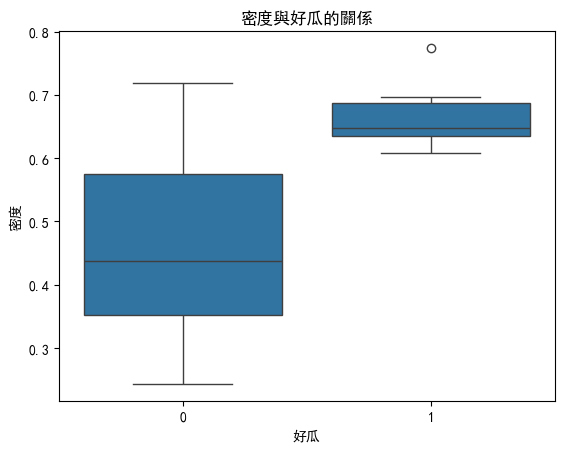

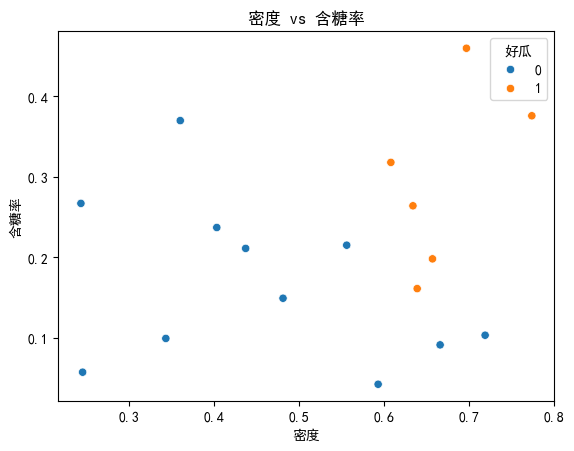

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #设置负号正常显示
sns.boxplot(x=y, y=df['密度'])
plt.title('密度與好瓜的關係')
plt.show()

sns.scatterplot(x=df['密度'], y=df['含糖率'], hue=y)
plt.title('密度 vs 含糖率')
plt.show()

## 5. 切分資料

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

## 6. 決策樹分類模型

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
print("測試準確率:", accuracy_score(y_test, y_pred))

測試準確率: 0.25


## 7. 交叉驗證

In [8]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(tree, X_encoded, y, cv=5)
print("五折交叉驗證平均準確率:", scores.mean())

五折交叉驗證平均準確率: 0.7499999999999999


## 8. 超參數調整

In [9]:
from sklearn.model_selection import GridSearchCV
param_grid = {'max_depth': [2, 3, 4], 'min_samples_split': [2, 3, 4]}
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_encoded, y)
print("最佳參數:", grid.best_params_)
print("最佳分數:", grid.best_score_)

最佳參數: {'max_depth': 3, 'min_samples_split': 4}
最佳分數: 0.8666666666666666


## 9. 決策樹可視化

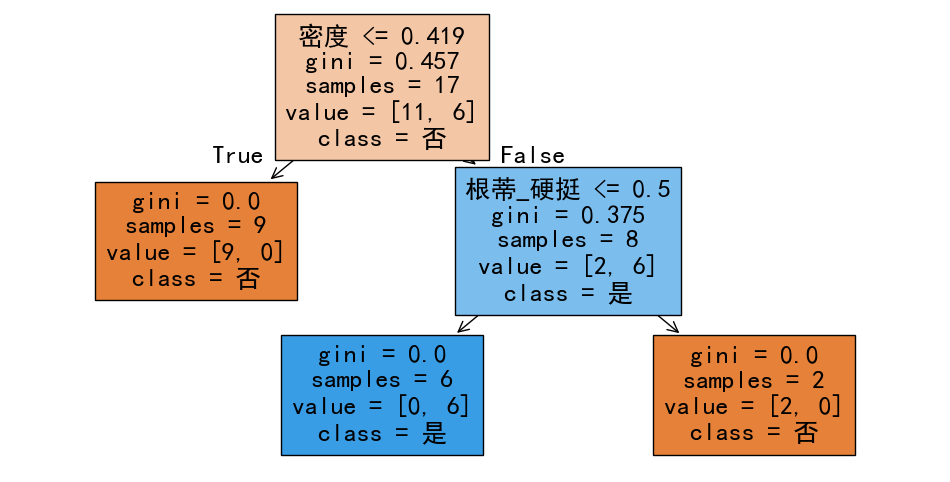

In [10]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 6))
plot_tree(grid.best_estimator_, feature_names=X_encoded.columns, class_names=['否', '是'], filled=True)
plt.show()

## 10. 與隨機森林模型比較

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("隨機森林準確率:", accuracy_score(y_test, rf_pred))
print("混淆矩陣:")
print(confusion_matrix(y_test, rf_pred))

隨機森林準確率: 1.0
混淆矩陣:
[[2 0]
 [0 2]]
